In [578]:
import pandas as pd
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

diabetes_df = pd.read_csv("../week_06/diabetes.csv")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Preprocessing

In [579]:
cols = ['Pregnancies', 'Glucose', 'BMI', 'SkinThickness', 'Insulin']

for col in cols:
    diabetes_df[col] = diabetes_df[col].replace(0, diabetes_df[col].median())

In [580]:
from sklearn.model_selection import train_test_split

X = diabetes_df.drop('Outcome',axis=1)
y = diabetes_df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=50)
                                                    

In [581]:
model = tree.DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=43
)

In [582]:
model = model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [583]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.76      0.79       148
           1       0.63      0.73      0.68        83

    accuracy                           0.75       231
   macro avg       0.73      0.75      0.74       231
weighted avg       0.76      0.75      0.75       231



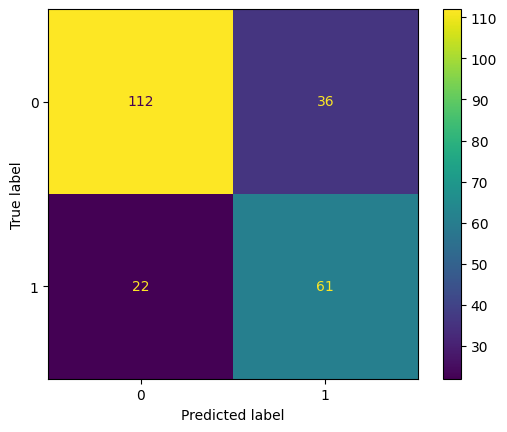

In [584]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [585]:
Precision_original = 61/(61+36)
Recall_original = 61/(61+22)

print("Precision =", Precision_original, "Recall =", Recall_original)

Precision = 0.6288659793814433 Recall = 0.7349397590361446


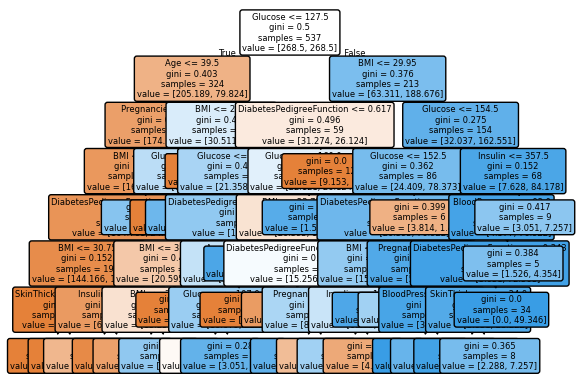

<Figure size 640x480 with 0 Axes>

In [586]:
import matplotlib.pyplot as plt
tree.plot_tree(model, feature_names = list(X.columns),
                filled = True, fontsize=6, rounded= True)

plt.show()
plt.savefig("tree.svg")

I have tried oversampling but I can only increase the recall and haven't figure out way to increase the precision

In [587]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [588]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=41)

ros = RandomOverSampler(random_state=50)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

In [589]:
model = LogisticRegression(random_state=43)
model.fit(X_resampled, y_resampled)

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,43
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [590]:
y_pred = model.predict(X_test)

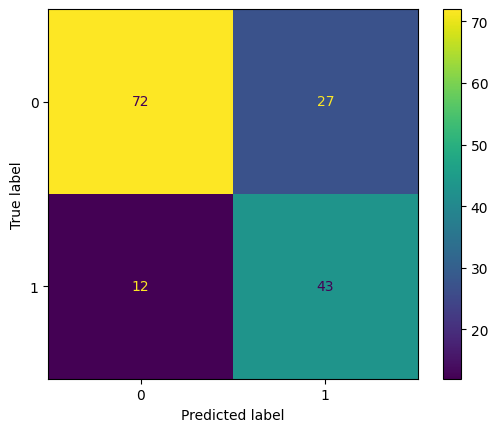

In [591]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [593]:
Precision_over = 43/(43+27)
Recall_over = 43/(43+12)

print("Precision =", Precision_over, "Recall =", Recall_over)

Precision = 0.6142857142857143 Recall = 0.7818181818181819


In [594]:
input = [{'name': 'Niles'}, {'name': 'C.C.'}, {'name': 'Fran'}]

def format_names(names):
    name_list = [person['name'] for person in names]
    
    if len(name_list) == 1:
        return name_list[0]
    if len(name_list) == 2:
        return name_list[0] + " & " + name_list[1]
    
    return ", ".join(name_list[:-1]) + " & " + name_list[-1]

print(format_names(input))



Niles, C.C. & Fran
